In [1]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap
from numba import njit, prange
from scipy.spatial import cKDTree

In [2]:
galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])

In [29]:
structured_vels = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(galaxy.gas["Velocities"]**2, axis=-1)), grid_size=300)

Slicing: 100%|██████████| 300/300 [00:10<00:00, 28.62it/s]


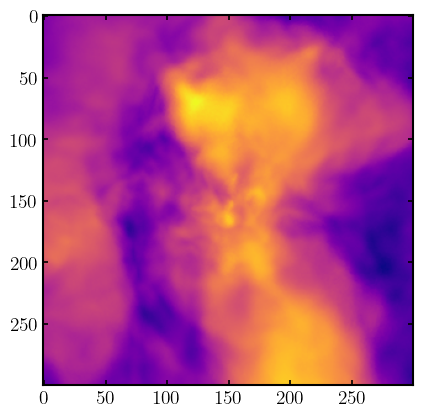

In [30]:
fig, ax = plt.subplots()
ax.imshow(np.log10(structured_vels), cmap="plasma", interpolation=None)

In [5]:
import time, sys
from numba.typed import List


def update_progress(fraction_done, bar_length=40):
    percent = int(fraction_done * 100)
    filled_len = int(bar_length * fraction_done)
    bar = '=' * filled_len + '-' * (bar_length - filled_len)
    sys.stdout.write(f'\r[{bar}] {percent:3d}%')
    sys.stdout.flush()


@njit
def init_mean_vels(N, velx, vely, velz, inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii):
    for i in range(N):
        bulkx = np.mean(velx[inds[i]])
        bulky = np.mean(vely[inds[i]])
        bulkz = np.mean(velz[inds[i]])
        previous_turbulentx[i] = velx[i] - bulkx
        previous_turbulenty[i] = vely[i] - bulky
        previous_turbulentz[i] = velz[i] - bulkz
        current_width[i] = max(current_width[i] + cell_radii[i], 1.05 * current_width[i])


@njit
def calculate_mean_vels(N, velx, vely, velz, inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii, shocks, coherence_length):
    for i in range(N):
        if len(inds[i]) < 2:
            continue
        bulkx = np.mean(velx[inds[i]])
        bulky = np.mean(vely[inds[i]])
        bulkz = np.mean(velz[inds[i]])

        delta = np.max(np.abs(np.array([velx[i] - bulkx, vely[i] - bulky, velz[i] - bulkz]) - 1))
        shocked = False
        for l in inds[i]:
            if shocks[l] > 1.3:
                shocked = True
                # print("im shocked")
                break
        if (delta < 0.05) or shocked:
            coherence_length[i] = current_width[i]
            current_width[i] = 0.0
        else:
            current_width[i] = max(current_width[i] + cell_radii[i], 1.05 * current_width[i])

        previous_turbulentx[i] = velx[i] - bulkx
        previous_turbulenty[i] = vely[i] - bulky
        previous_turbulentz[i] = velz[i] - bulkz


def box_smoothing_velocity_decomposition(positions, velocities, masses, density, shocks):
    N = positions.shape[0]
    vols = masses/density
    cell_radii = (3/(4*np.pi) * vols)**(1/3)
    current_width = 3 * cell_radii
    velx = velocities[:, 0]
    vely = velocities[:, 1]
    velz = velocities[:, 2]
    previous_turbulentx = np.zeros_like(velx)
    previous_turbulenty = np.zeros_like(velx)
    previous_turbulentz = np.zeros_like(velx)
    coherence_scale = np.zeros(len(positions))

    tree = cKDTree(positions)
    inds = tree.query_ball_point(positions, current_width, workers=8)
    numba_inds = List()
    for ind_list in inds:
        numba_inds.append(np.array(ind_list))

    init_mean_vels(N, velx, vely, velz, numba_inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii)

    while np.sum(current_width) > 0:
        update_progress(np.sum(current_width == 0.0)/len(positions))
        inds = tree.query_ball_point(positions, current_width, workers=8)
        numba_inds = List()
        for ind_list in inds:
            numba_inds.append(np.array(ind_list))
        calculate_mean_vels(N, velx, vely, velz, numba_inds, previous_turbulentx, previous_turbulenty, previous_turbulentz, current_width, cell_radii, shocks, coherence_scale)
    
    previous_turbulent = np.column_stack((previous_turbulentx, previous_turbulenty, previous_turbulentz))
    return velocities - previous_turbulent, previous_turbulent, coherence_scale

In [6]:
not_center = np.linalg.norm(galaxy.gas["Coordinates"] - galaxy.bhs["Coordinates"][0], axis=-1) > 350

turb = box_smoothing_velocity_decomposition(galaxy.gas["Coordinates"][not_center], galaxy.gas["Velocities"][not_center], galaxy.gas["Masses"][not_center], 
                                            galaxy.gas["Density"][not_center], galaxy.gas["Machnumber"][not_center])

[=======================================-]  99%

In [7]:
structured_vels = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(galaxy.gas["Velocities"]**2, axis=-1)), grid_size=300)
structured_vels_back = nicegalaxy.structured_column(galaxy.gas["Coordinates"][not_center], np.sqrt(np.sum(turb[0]**2, axis=-1)), grid_size=300)
structured_vels_turb = nicegalaxy.structured_column(galaxy.gas["Coordinates"][not_center], np.sqrt(np.sum(turb[1]**2, axis=-1)), grid_size=300)

Slicing: 100%|██████████| 300/300 [02:03<00:00,  2.44it/s]


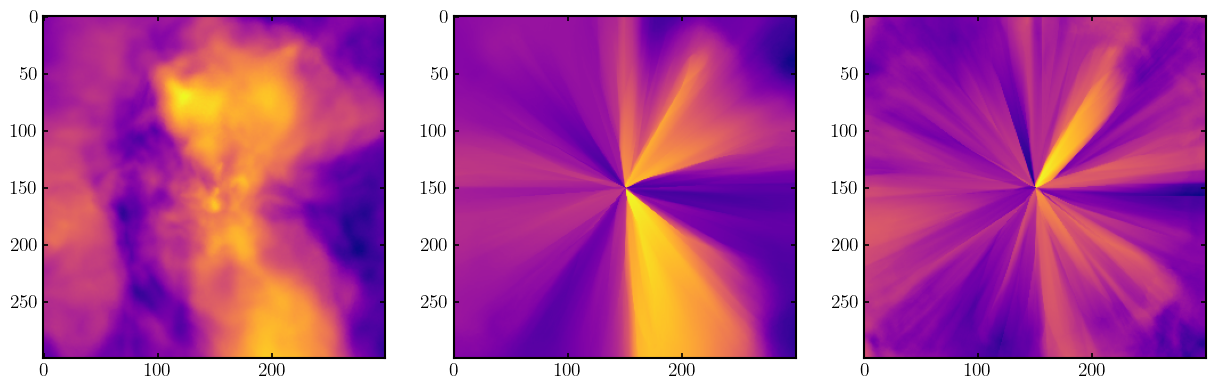

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(np.log10(structured_vels), interpolation=None, cmap="plasma")
ax[1].imshow(np.log10(structured_vels_back), interpolation=None, cmap="plasma")
ax[2].imshow(np.log10(structured_vels_turb), interpolation=None, cmap="plasma")

Slicing: 100%|██████████| 800/800 [01:36<00:00,  8.31it/s]


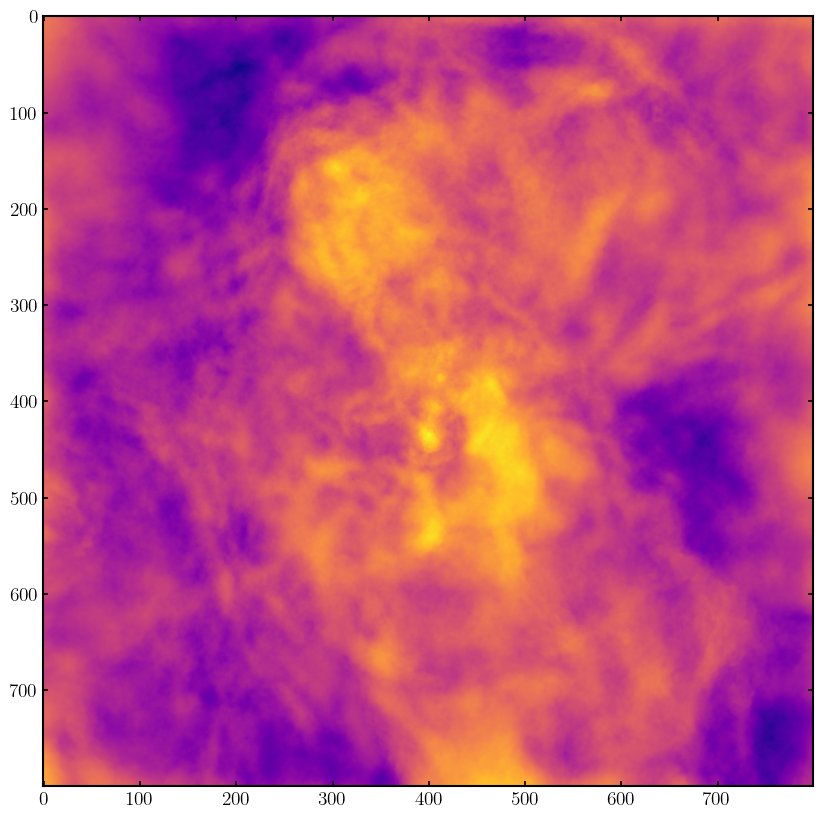

In [37]:
structured_vels_turb = nicegalaxy.structured_column(galaxy.gas["Coordinates"][not_center], np.sqrt(np.sum(turb[1]**2, axis=-1)), grid_size=800)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(np.log10(structured_vels_turb), interpolation=None, cmap="plasma")

Slicing: 100%|██████████| 200/200 [00:37<00:00,  5.38it/s]


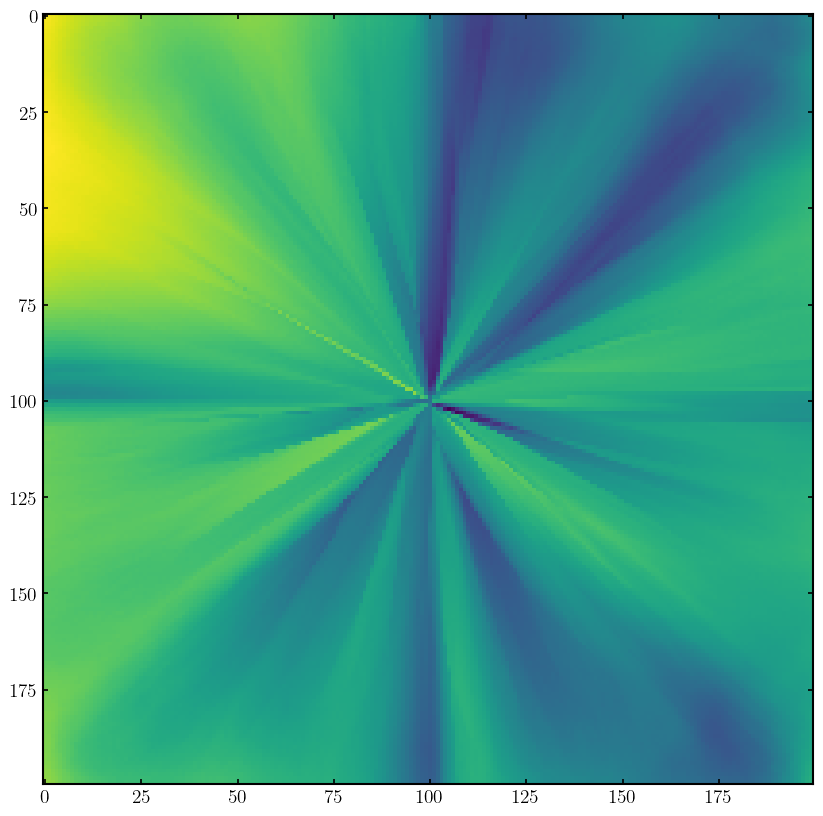

In [9]:
structured = nicegalaxy.structured_column(galaxy.gas["Coordinates"][not_center], turb[2], grid_size=200)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(np.log10(structured), interpolation=None)

In [11]:
nicegalaxy.galaxies[3]

498522

In [9]:
import glob, os

def get_velocity_filenames():
    cutout_path = "/u/jbiba/projects/milkyway-turbulence/data/turb-vels"
    galaxies_hdf5 = glob.glob(os.path.join(cutout_path, '*.h5'))
    galaxies = [int((os.path.basename(f)).split(".")[0]) for f in galaxies_hdf5]
    return galaxies


def get_turb_velocities(id):
    turb = dict()
    with h5py.File("/u/jbiba/projects/milkyway-turbulence/data/turb-vels/" + f"{id}.h5", "r") as f:
        for key in f:
            turb[key] = np.array(f[key])
    return turb


turb_galaxies = get_velocity_filenames()

In [12]:
turb = get_turb_velocities(turb_galaxies[30])
galaxy = nicegalaxy.Galaxy(turb_galaxies[30])

In [13]:
structured_vels = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(galaxy.gas["Velocities"]**2, axis=-1)), grid_size=300)
structured_vels_back = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum((galaxy.gas["Velocities"] - turb["TurbVelocities"])**2, axis=-1)), grid_size=300)
structured_vels_turb = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(turb["TurbVelocities"]**2, axis=-1)), grid_size=300)
structured_scale = nicegalaxy.structured_column(galaxy.gas["Coordinates"], turb["CoherenceScale"], grid_size=300)

Slicing: 100%|██████████| 300/300 [00:07<00:00, 38.58it/s]


In [1]:
from matplotlib.ticker import ScalarFormatter


fig, axs = plt.subplots(2, 2, figsize=(15, 15))

cutout_size = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()
scalebar_length = round(cutout_size/10)
scalebar_pixels = scalebar_length/cutout_size * structured_vels.shape[0]

vmin = structured_vels.min()
vmax = structured_vels.max()
im00 = axs[0, 0].imshow(structured_vels, interpolation=None, cmap="plasma", norm="log")
im01 = axs[0, 1].imshow(structured_vels_back, interpolation=None, cmap="plasma", norm="log")
im10 = axs[1, 0].imshow(structured_vels_turb, interpolation=None, cmap="plasma", norm="log")
im11 = axs[1, 1].imshow(structured_scale, interpolation=None, cmap="viridis", norm="log")
ims = [[im00, im01], [im10, im11]]

labels = [[r"$|v|$ [km/s]", r"$|v|$ [km/s]"], [r"$|v|$ [km/s]", r"$d_\mathrm{smooth}$ [kpc]"]]

for i in range(2):
    for j in range(2):
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].plot([structured_vels.shape[0]*(1 - 1/40) - scalebar_pixels, structured_vels.shape[0]*(1 - 1/40)], [structured_vels.shape[0]/40, structured_vels.shape[0]/40], color='white', linewidth=1)
        axs[i, j].text(structured_vels.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_vels.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("bottom", size="5%", pad=0.05)
        cbar = plt.colorbar(ims[i][j], cax=cax, orientation="horizontal", label=labels[i][j])

fig.tight_layout()

NameError: name 'plt' is not defined

In [77]:
import concurrent.futures


def mean(vals, weights):
    if len(vals.shape) == 1:
        return np.sum(vals*weights)/np.sum(weights)
    else:
        return np.sum(vals*weights[:, None], axis=0)/np.sum(weights)


def variance(vals, weights):
    return np.sqrt(mean(vals**2, weights) - mean(vals, weights)**2)


def rms(vals, weights):
    return np.sqrt(np.sum(np.sum(vals**2, axis=-1)*weights)/np.sum(weights))


def cutout_calculation(boxes, smoothing):
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

    min_corner = galaxy.gas["Coordinates"].min(axis=0)
    max_corner = galaxy.gas["Coordinates"].max(axis=0)
    cutout_size = box_length/2**smoothing

    spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)

    measurments = ["distGC", "MachNumber", "BulkVel"]
    table = {key: np.zeros(boxes**3, dtype=np.float64) for key in measurments}

    def cutout_calculation(i, j, k):
        cutout_min = min_corner + np.array([i, j, k]) * spacing
        cutout_max = cutout_min + cutout_size
        in_box = (
            (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
            (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
            (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
        )
        if len(galaxy.gas["Coordinates"][in_box]) == 0:
            return
        center = 0.5 * (cutout_max + cutout_min)
        gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))

        cutout_idx = i * boxes**2 + j * boxes + k
        table["distGC"][cutout_idx] = gc_dist
        vols = galaxy.gas["Masses"][in_box]/galaxy.gas["Density"][in_box]
        soundspeed = np.sqrt(5/3 * (5/3 - 1) * galaxy.gas["InternalEnergy"][in_box])
        vel_bulk_v = mean(turb["TurbVelocities"][in_box], vols)
        mach = rms((turb["TurbVelocities"][in_box] - vel_bulk_v)/soundspeed[:, np.newaxis], vols)
        table["MachNumber"][cutout_idx] = mach
        table["BulkVel"][cutout_idx] = np.linalg.norm(vel_bulk_v)
        

    tasks = [(i, j, k) for i in range(boxes) for j in range(boxes) for k in range(boxes)]
    thread_results = []
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = [executor.submit(cutout_calculation, i, j, k) for i, j, k in tasks]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            thread_results.append(future.result())
    return table

In [78]:
table60 = cutout_calculation(20, 3)
table30 = cutout_calculation(20, 4)
table15 = cutout_calculation(20, 5)

100%|██████████| 8000/8000 [00:13<00:00, 578.79it/s]


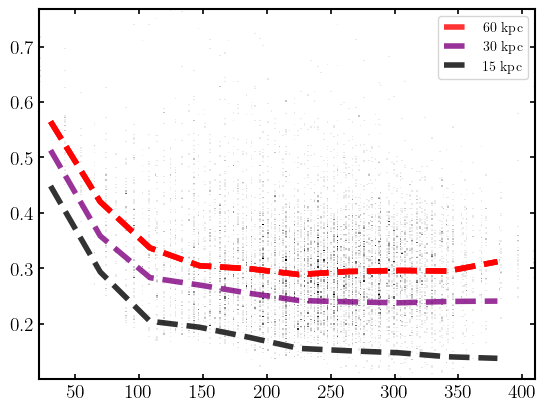

In [86]:
fig, ax = plt.subplots()

X = table60["distGC"]
Y = table60["MachNumber"]
ax.hist2d(X, Y, bins=300, cmap="Greys")

total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8)

Y = table30["MachNumber"]
running_median_30 = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8)

Y = table15["MachNumber"]
running_median_15 = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60 kpc")
ax.plot(bins-delta/2, running_median_30,'--', color="purple", lw=4,alpha=.8, label="30 kpc")
ax.plot(bins-delta/2, running_median_15,'--', color="black", lw=4,alpha=.8, label="15 kpc")
ax.legend()


fig.show()

In [75]:
table60["distGC"][:20**3]

array([410.0294252 , 396.16451444, 383.41951186, ..., 383.44941789,
       396.19409539, 410.05862137], shape=(8000,))

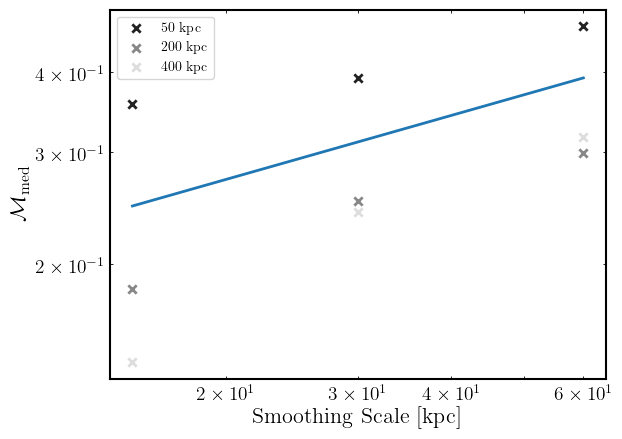

In [93]:
fig, ax = plt.subplots()
turb_dists = [50, 200, 400]
colors = list(reversed(['#dddddd', '#888888', '#222222']))
windows = [20, 10, 20]

value = "MachNumber"
for i, turb_dist in enumerate(turb_dists):
    Y = table60[f"{value}"][(table60["distGC"] > turb_dist - windows[i]) & (table60["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([60], [medY], color=colors[i], label=f'{turb_dist} kpc', marker="x")

for i, turb_dist in enumerate(turb_dists):
    Y = table30[f"{value}"][(table30["distGC"] > turb_dist - windows[i]) & (table30["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([30], [medY], color=colors[i], marker="x")

for i, turb_dist in enumerate(turb_dists):
    Y = table15[f"{value}"][(table15["distGC"] > turb_dist - windows[i]) & (table15["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([15], [medY], color=colors[i], marker="x")

x = np.linspace(15, 60)
y = 0.1 * x**(1/3)
ax.plot(x, y)
ax.legend()
ax.set_ylabel(r"$\mathcal{M}_{\mathrm{med}}$")
ax.set_xlabel(r"Smoothing Scale [kpc]")
ax.set_xscale("log")
ax.set_yscale("log")
fig.show()